In [26]:
pip install folium

In [27]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [29]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [30]:
df.shape

(20640, 10)

In [31]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [32]:
df.dropna(inplace=True)

In [33]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [35]:
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

<Axes: >

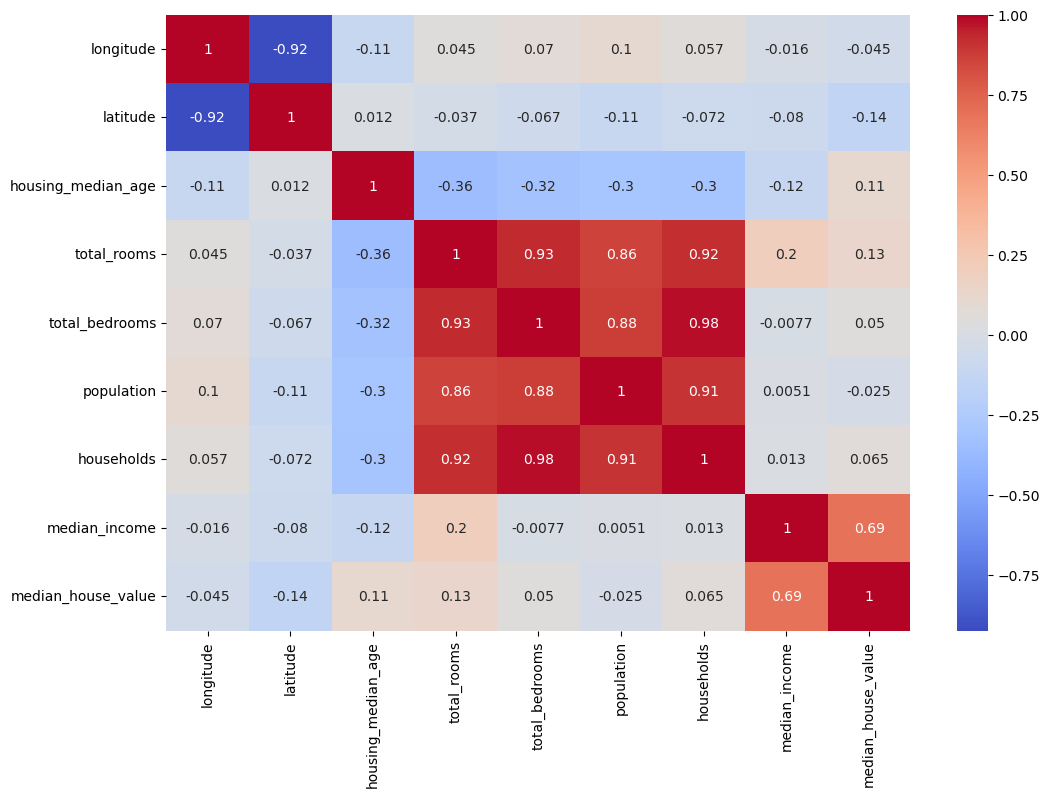

In [36]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(data=cor, annot=True, cmap="coolwarm")

In [37]:
import folium

# Create map
m = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=6
)

# Add points with value
for _, row in df.sample(500).iterrows():  # limit points for speed
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="blue",
        fill=True,
        fill_opacity=0.6,
        tooltip=f"House Value: ${row['median_house_value']:,.0f}"
    ).add_to(m)

m

In [38]:
X = df.drop(["median_house_value"], axis=1)
y = df["median_house_value"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
baseline = y_train.mean()

# create constant predictions using pure Python
baseline_pred = [baseline] * len(y_test)
baseline_pred

[np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float64(206644.40009788328),
 np.float6

In [ ]:
categorical = ["ocean_proximity"]
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(), categorical)
], remainder="passthrough")

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

In [ ]:
import pickle

# save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
ls

In [ ]:
cd Projects\week_3

In [ ]:
!streamlit run app.py
